In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Customer_shopping_data.csv")
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [4]:
df.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [5]:
df.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['invoice_date']=pd.to_datetime(df['invoice_date'], format='%d/%m/%Y')

In [8]:
df.dtypes

invoice_no                object
customer_id               object
gender                    object
age                        int64
category                  object
quantity                   int64
price                    float64
payment_method            object
invoice_date      datetime64[ns]
shopping_mall             object
dtype: object

In [9]:
df['total_price']=df['quantity']*df['price']
df.columns

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall',
       'total_price'],
      dtype='object')

In [10]:
import datetime as dt

snapshot_date = df['invoice_date'].max() + dt.timedelta(days=1)

rfm = df.groupby('customer_id').agg({
    'invoice_date': lambda x: (snapshot_date - x.max()).days,
    'invoice_no': 'nunique',
    'total_price': 'sum'
})

rfm.columns = ['recency', 'frequency', 'monetary']
rfm.head()

,recency,frequency,monetary
customer_id,,,
C100004,468,1,7502.00
C100005,6,1,2400.68
C100006,98,1,322.56
C100012,571,1,130.75
C100019,592,1,35.84


In [11]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
rfm_scaled=scaler.fit_transform(rfm)

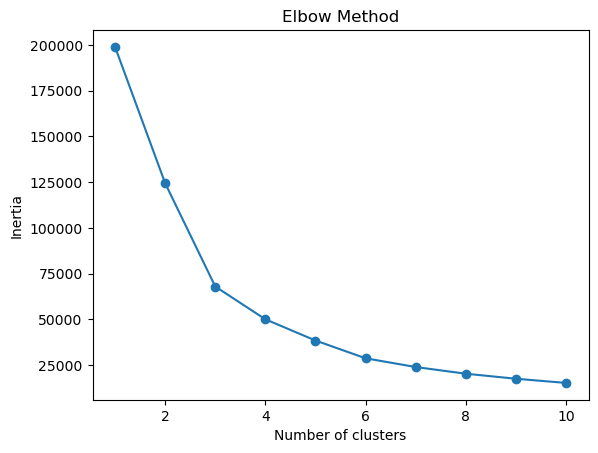

In [12]:
from sklearn.cluster import KMeans

inertia=[]
for k in range (1,11):
    kmeans=KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [13]:
kmeans_final=KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['clusters']=kmeans_final.fit_predict(rfm_scaled)
rfm.head()

,recency,frequency,monetary,clusters
customer_id,,,,
C100004,468,1,7502.00,2
C100005,6,1,2400.68,0
C100006,98,1,322.56,0
C100012,571,1,130.75,1
C100019,592,1,35.84,1


In [14]:
rfm.groupby('clusters')[['recency','frequency','monetary']].mean()

,recency,frequency,monetary
clusters,,,
0,195.909470,1.0,1309.407132
1,601.464533,1.0,1356.569239
2,392.933824,1.0,11883.199600


In [15]:
rfm.drop('frequency',axis=1,inplace=True)
rfm.head()

,recency,monetary,clusters
customer_id,,,
C100004,468,7502.00,2
C100005,6,2400.68,0
C100006,98,322.56,0
C100012,571,130.75,1
C100019,592,35.84,1


In [16]:
customer_names={
    0 : 'Recent Customers',
    1 : 'Lost Customers',
    2 : 'High-Value Customers'
}
rfm['segment']=rfm['clusters'].map(customer_names)
rfm.head()

,recency,monetary,clusters,segment
customer_id,,,,
C100004,468,7502.00,2,High-Value Customers
C100005,6,2400.68,0,Recent Customers
C100006,98,322.56,0,Recent Customers
C100012,571,130.75,1,Lost Customers
C100019,592,35.84,1,Lost Customers


In [17]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine

load_dotenv()

username = os.getenv("DB_USERNAME")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

In [18]:
table1_name = 'transactions'
table2_name = 'customer_segments'

df.to_sql(table1_name, engine, if_exists='replace', index=False)
rfm.to_sql(table2_name, engine, if_exists='replace', index=True)

457